In [1]:
from IPython.display import IFrame
IFrame("./IntentoDeTPL7.v0.1.pdf", width=1000, height=1000)

In [2]:
import sympy as sp

from pytc2.cuadripolos import calc_MAI_impedance_ij
from pytc2.general import print_latex

# T puenteado cargado: red de R constante
'''
Numeración de nodos:

            |------Ya-------|
            |               |
    0-------+--G----2---G---3
                    |       |
                   Yb       G
                    |       |
    1---------------+--------

'''

Ya, Yb = sp.symbols('Ya Yb', complex=True)
G = sp.symbols('G', real=True, positive=True)

# Armo la MAI
Ymai = sp.Matrix([
    [ Ya+G,   0,      -G,     -Ya],
    [ 0,     Yb+G,    -Yb,    -G],
    [ -G,   -Yb,      2*G+Yb, -G],
    [ -Ya,   -G,     -G,      2*G+Ya ]
])

# Activar detalles si se quiere depuración
con_detalles = False

# ========================================
# Cálculo de impedancia de entrada Z_in
# Puerto entre nodos 0 (entrada) y 1 (masa)
# ========================================
Zin = calc_MAI_impedance_ij(Ymai, 0, 1, verbose=con_detalles)

print('Impedancia de entrada general:')
print_latex(r'Z_{in} = ' + sp.latex(Zin))

# Aplicamos la condición de R constante: G^2 = Ya * Yb
Zin_Rconst = sp.simplify(Zin.subs(Ya*Yb, G**2))

print('Aplicando condición de R constante:')
print_latex(r'G^2 = Y_a \cdot Y_b')
print_latex(r'Z_{in} = ' + sp.latex(Zin_Rconst))


Impedancia de entrada general:


<IPython.core.display.Math object>

Aplicando condición de R constante:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
import sympy as sp
from pytc2.general import print_latex

# T puenteado cargado: red de R constante
Ya, Yb = sp.symbols('Ya Yb', complex=True)
G = sp.symbols('G', real=True, positive=True)

# MAI original (4 nodos)
Ymai = sp.Matrix([
    [ Ya+G,   0,      -G,     -Ya],
    [ 0,     Yb+G,    -Yb,    -G],
    [ -G,   -Yb,      2*G+Yb, -G],
    [ -Ya,   -G,     -G,      2*G+Ya ]
])

# ------------------------------
# Nodos de puertos: (0,1) y (3,1)
# Nodos internos: [2]
# Vamos a reducir la MAI por eliminación de nodo interno (2)
# ------------------------------
# Particiono: nodos [0,3] (puertos) y nodo interno [2]
Yaa = Ymai.extract([0,3],[0,3])    # matriz entre nodos externos
Yab = Ymai.extract([0,3],[2])      # acople externo-interno
Yba = Ymai.extract([2],[0,3])      # acople interno-externo
Ybb = Ymai.extract([2],[2])        # interna

# Reducción de Kron
Y_red = Yaa - Yab * (Ybb.inv()) * Yba

# Y_red está en nodos (0 y 3) respecto a masa (1)
# Esto corresponde a matriz Y del cuadripolo
Y11 = Y_red[0,0]
Y12 = Y_red[0,1]
Y21 = Y_red[1,0]
Y22 = Y_red[1,1]

Y_matrix = sp.Matrix([[Y11, Y12],[Y21,Y22]])
print("Matriz Y del cuadripolo:")
print_latex(r'\mathbf{Y} = ' + sp.latex(sp.simplify(Y_matrix)))

# ------------------------------
# Matriz Z = inversa de Y
# ------------------------------
Z_matrix = sp.simplify(Y_matrix.inv())
print("Matriz Z del cuadripolo:")
print_latex(r'\mathbf{Z} = ' + sp.latex(Z_matrix))

# ------------------------------
# Matriz T (ABCD)
# ------------------------------
# T = [[A,B],[C,D]] con:
# A = Z11 / Z21
# B = det(Z) / Z21
# C = 1 / Z21
# D = Z22 / Z21
A = Z_matrix[0,0]/Z_matrix[1,0]
B = sp.simplify(sp.det(Z_matrix)/Z_matrix[1,0])
C = 1/Z_matrix[1,0]
D = Z_matrix[1,1]/Z_matrix[1,0]

T_matrix = sp.Matrix([[sp.simplify(A),sp.simplify(B)],
                      [sp.simplify(C),sp.simplify(D)]])
print("Matriz T (ABCD):")
print_latex(r'\mathbf{T} = ' + sp.latex(T_matrix))


Matriz Y del cuadripolo:


<IPython.core.display.Math object>

Matriz Z del cuadripolo:


<IPython.core.display.Math object>

Matriz T (ABCD):


<IPython.core.display.Math object>

In [4]:
import sympy as sp

# Netlist en formato texto
netlist = """R1 3 1 1
R2 4 3 1
R§ZB 0 3 1
R§ZA 1 4 1
R 4 0 1
"""

# Parsear líneas
lines = [ln.strip() for ln in netlist.splitlines() if ln.strip()]

# Nodos (excluimos 0 = masa)
nodes = [1, 3, 4]  # orden inicial

# Construir matriz Y
n = len(nodes)
Y = sp.zeros(n)

def idx(node):
    return nodes.index(node)

for ln in lines:
    _, n1, n2, val = ln.split()
    n1, n2 = int(n1), int(n2)
    G = 1 / sp.sympify(val)
    if n1 != 0:
        Y[idx(n1), idx(n1)] += G
    if n2 != 0:
        Y[idx(n2), idx(n2)] += G
    if n1 != 0 and n2 != 0:
        Y[idx(n1), idx(n2)] -= G
        Y[idx(n2), idx(n1)] -= G

# Reordenar para [1,4|3] (puertos primero)
perm = [0, 2, 1]
Yp = Y[perm, :][:, perm]

# Particionar
Y_pp = Yp[:2, :2]
Y_pi = Yp[:2, 2:]
Y_ip = Yp[2:, :2]
Y_ii = Yp[2:, 2:]

# Eliminar nodo interno y calcular Z
Y_2p = sp.simplify(Y_pp - Y_pi * (Y_ii.inv()) * Y_ip)
Z = sp.simplify(Y_2p.inv())

print("Matriz Z:")
sp.pprint(Z)


Matriz Z:
⎡ 1   1/2⎤
⎢        ⎥
⎣1/2  5/8⎦


Si en el LTSpice defino las impedancias de este modo 

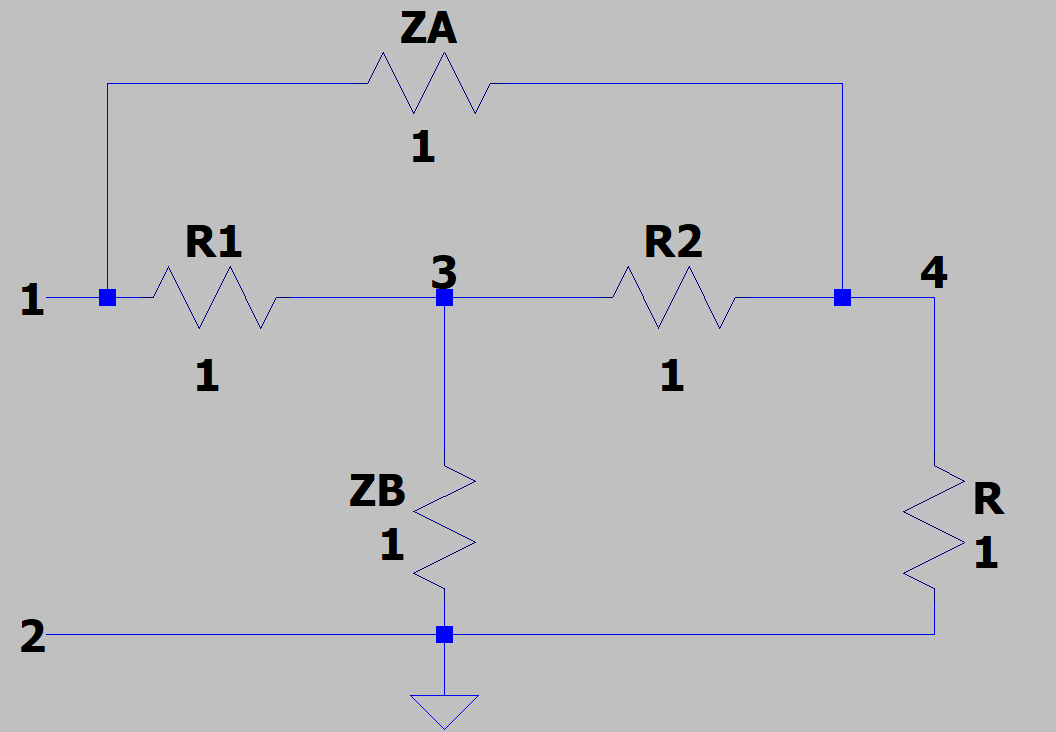

-----------------------------------------------------------------------

Segundo punto 

In [5]:
import sympy as sp
from pytc2.general import print_latex

# Variables simbólicas
s = sp.symbols('s')
K = sp.sqrt(2)

# Funciones para matrices T
def T_series(Z):
    return sp.Matrix([[1, Z],[0, 1]])

def T_shunt(Y):
    return sp.Matrix([[1, 0],[Y, 1]])

def T_gyrator(K):
    return sp.Matrix([[0, 1/K],[K, 0]])

# Elementos del circuito
Zc = 2/s                              # Z del capacitor 0.5
Ysh = 0.5*s + 1/(2*s)                 # Admitancia central

# Matrices individuales
T_C = T_series(Zc)
T_G = T_gyrator(K)
T_Shunt = T_shunt(Ysh)

# Matriz total (producto en cascada)
T_total = sp.simplify(T_C * T_G * T_Shunt * T_G * T_C)

print("Matriz T (ABCD):")
print_latex(r'\mathbf{T} = ' + sp.latex(T_total))


Matriz T (ABCD):


<IPython.core.display.Math object>

Por ahora se me es imposible sacar la simulacion de Spice : 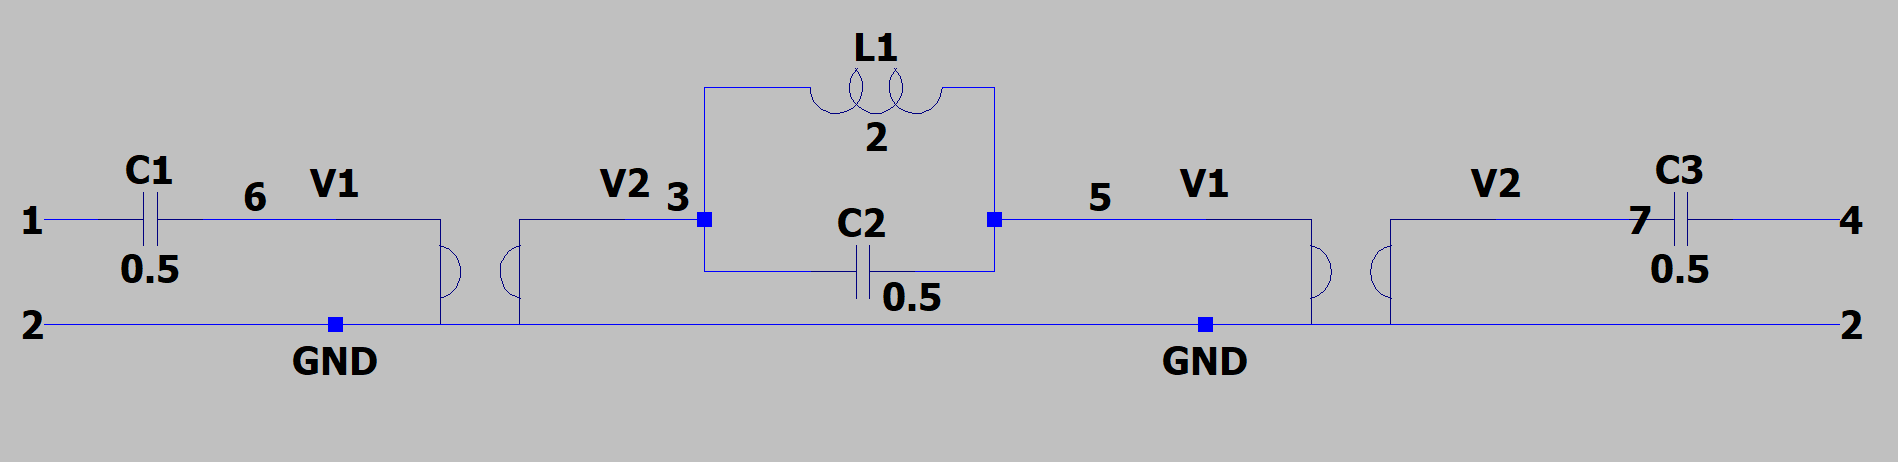